In [14]:
import os, sys
from pathlib import Path
import yaml
import mintflow
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm
import numpy as np
from pprint import pprint
import pickle
import anndata
import gc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from datetime import datetime
import mintflow
import mintflow.interface.perturbation.module_gen_micsizefactor
import mintflow.interface.perturbation.module_gen_stdata
import squidpy as sq
import re

In [7]:
import mintflow.utils_flowmatching as uf 
uf.FMLossCombinationMode = uf.ModeFMLoss # compatibility 


model_checkpoint = '/nfs/team361/am74/mintflow/revision/train_model_all_data/window_sz_2280_alldatawithbatcheffect/8epochs_save_h5ad/new_hyperparametes/run2/outputs/model_epoch_7.pt'
model = torch.load(
    model_checkpoint,
    map_location='cpu',
    weights_only=False
)
model.to(device)
cache_path = "/lustre/scratch126/cellgen/lotfollahi/zh4/Mintflow/cache/mintflow_context.pkl"

with open(cache_path, "rb") as f:
    data_mintflow, dict_all4_configs = pickle.load(f)
print(f"Loaded cached context: {cache_path}")

Loaded cached context: /lustre/scratch126/cellgen/lotfollahi/zh4/Mintflow/cache/mintflow_context.pkl


In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [8]:
adata_crops = sc.read_h5ad("/nfs/team361/cl35/MintFlow_reproducibility/all_8_crops_combined.h5ad")

if "slide_name" in adata_crops.obs.columns:
    slide_labels = adata_crops.obs["slide_name"].astype(str)
else:
    slide_labels = adata_crops.obs_names.to_series().str.split("__").str[0]

slide_order = [
    "CV1-KID-0-FO-1",
    "CV1-KID-0-FT-2",
    "CV5-KID-0-FO-1",
    "CV6-KID-0-FT-1",
    "CV7-KID-0-FT-2-s3",
    "CV9-KID-0-FT-2",
    "DI10-KID-0-FT-3",
    "DI13-KID-0-FT-1",
]

name_map = {slide: slide.replace("-", "_") for slide in slide_order}

for slide in slide_order:
    var_name = name_map[slide]
    ad_sub = adata_crops[slide_labels == slide].copy()
    globals()[var_name] = ad_sub

adatas = {
    "CV1_KID_0_FO_1": CV1_KID_0_FO_1,
    "CV1_KID_0_FT_2": CV1_KID_0_FT_2,
    "CV5_KID_0_FO_1": CV5_KID_0_FO_1,
    "CV6_KID_0_FT_1": CV6_KID_0_FT_1,
    "CV7_KID_0_FT_2_s3": CV7_KID_0_FT_2_s3,
    "CV9_KID_0_FT_2": CV9_KID_0_FT_2,
    "DI10_KID_0_FT_3": DI10_KID_0_FT_3,
    "DI13_KID_0_FT_1": DI13_KID_0_FT_1,
}

print("Loaded objects:")
for k, v in adatas.items():
    print(k, v.shape)

Loaded objects:
CV1_KID_0_FO_1 (37038, 5001)
CV1_KID_0_FT_2 (16851, 5001)
CV5_KID_0_FO_1 (16649, 5001)
CV6_KID_0_FT_1 (9900, 5001)
CV7_KID_0_FT_2_s3 (5791, 5001)
CV9_KID_0_FT_2 (9158, 5001)
DI10_KID_0_FT_3 (6480, 5001)
DI13_KID_0_FT_1 (2724, 5001)


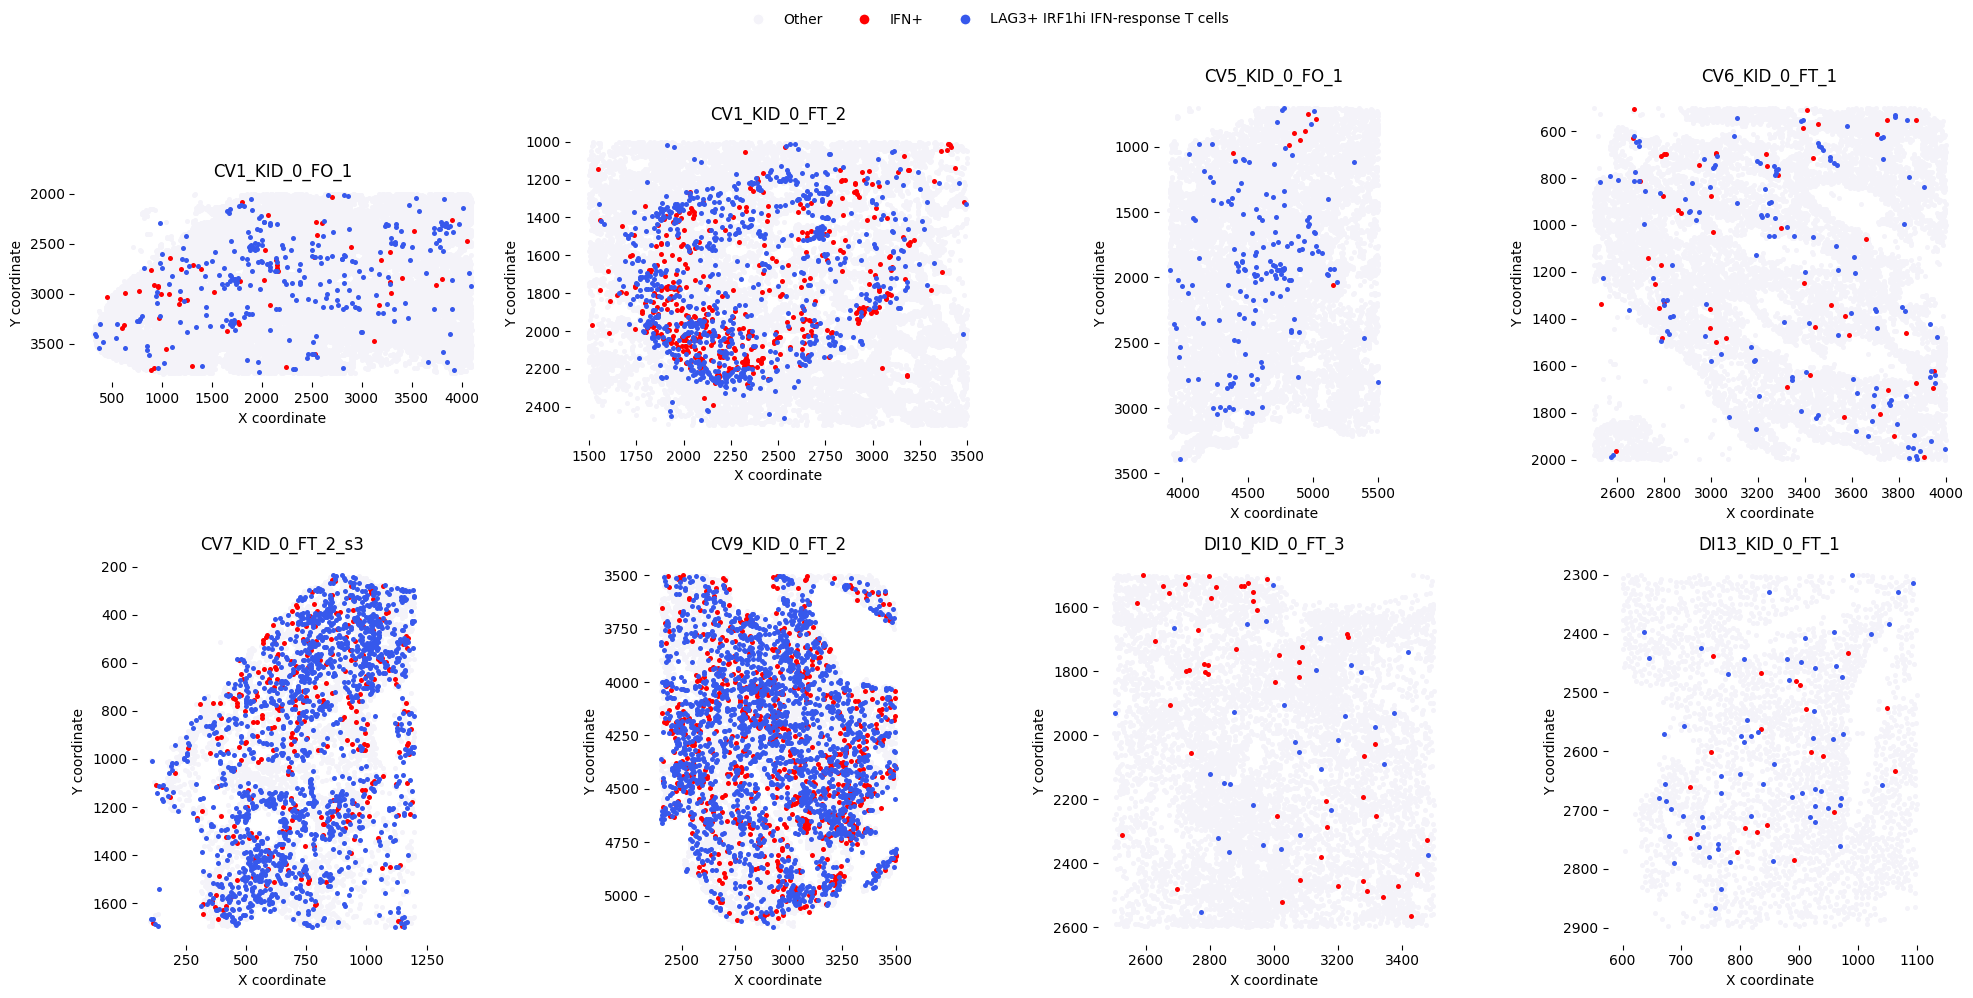

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (name, ad) in zip(axes, adatas.items()):
    vals = ad.obs["Annotation_Merged"].astype("object").copy().fillna("NA")
    vals_plot = vals.copy()
    vals_plot[~vals_plot.isin(["IFN+", "LAG3+ IRF1hi IFN-response T cells"])] = "Other"
    ad.obs["Annotation_Merged_IFNfocused"] = vals_plot

    m_other = ad.obs["Annotation_Merged_IFNfocused"] == "Other"
    m_ifn = ad.obs["Annotation_Merged_IFNfocused"] == "IFN+"
    m_lag3 = ad.obs["Annotation_Merged_IFNfocused"] == "LAG3+ IRF1hi IFN-response T cells"

    # background
    ax.scatter(
        ad.obs.loc[m_other, "x_centroid"],
        -ad.obs.loc[m_other, "y_centroid"],
        s=13,
        c="#f4f3f9",
        linewidths=0,
        rasterized=True
    )

    # IFN+ TAMs
    ax.scatter(
        ad.obs.loc[m_ifn, "x_centroid"],
        -ad.obs.loc[m_ifn, "y_centroid"],
        s=13,
        c="#ff0000",
        linewidths=0,
        rasterized=True
    )

    # IFN-related T cells
    ax.scatter(
        ad.obs.loc[m_lag3, "x_centroid"],
        -ad.obs.loc[m_lag3, "y_centroid"],
        s=13,
        c="#3658ec",
        linewidths=0,
        rasterized=True
    )

    ax.set_title(name)
    ax.set_aspect("equal")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{int(-v)}"))

    for spine in ax.spines.values():
        spine.set_visible(False)

# one shared legend
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#f4f3f9", markersize=8, label="Other"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#ff0000", markersize=8, label="IFN+"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#3658ec", markersize=8, label="LAG3+ IRF1hi IFN-response T cells"),
]
fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [10]:
import copy
import matplotlib.colors as mcolors

def make_anndata_write_safe(adata):
    """
    Return a copy of adata with uns color lists converted to plain hex strings,
    so .write() does not fail on mixed tuple/string color entries.
    """
    ad = adata.copy()
    ad.uns = copy.deepcopy(ad.uns)

    for k in list(ad.uns.keys()):
        if k.endswith("_colors"):
            vals = ad.uns[k]
            safe_vals = []
            for v in vals:
                try:
                    safe_vals.append(mcolors.to_hex(v))
                except Exception:
                    safe_vals.append(str(v))
            ad.uns[k] = safe_vals

    return ad

In [15]:
import numpy as np
import pandas as pd

def build_df_gene_perturbation(
    adata,
    perturbation_dict,
    obskey_celltype="Annotation_Merged",
    default_action="DC",
    allow_missing_genes=False,
    allow_missing_celltypes=False,
):
    if obskey_celltype not in adata.obs.columns:
        raise KeyError(f"{obskey_celltype!r} not found in adata.obs")

    valid_actions_prefix = ("KO", "DC", "UP:")
    var_names = adata.var_names.tolist()
    gene_set = set(var_names)

    arr = np.full((adata.n_obs, adata.n_vars), default_action, dtype="U20")
    gene_to_idx = {g: i for i, g in enumerate(var_names)}

    celltypes = adata.obs[obskey_celltype].astype("object")
    available_celltypes = set(celltypes.dropna().unique())

    for gene, target_to_action in perturbation_dict.items():
        if gene not in gene_set:
            msg = f"Gene {gene!r} not found in adata.var_names"
            if allow_missing_genes:
                print(f"Skipping: {msg}")
                continue
            raise KeyError(msg)

        if not isinstance(target_to_action, dict):
            raise TypeError(
                f"Value for gene {gene!r} must be a dict like "
                f"{{'T cells': 'KO'}} or {{'All': 'UP:2'}}"
            )

        g_idx = gene_to_idx[gene]

        for target, action in target_to_action.items():
            if not isinstance(action, str) or not action.startswith(valid_actions_prefix):
                raise ValueError(
                    f"Invalid action {action!r} for gene {gene!r}. "
                    f"Allowed: 'KO', 'DC', or 'UP:<number>'"
                )

            if action.startswith("UP:"):
                try:
                    float(action.split("UP:")[1])
                except Exception:
                    raise ValueError(
                        f"Invalid UP action {action!r} for gene {gene!r}. "
                        f"Expected format like 'UP:2' or 'UP:2.0'"
                    )

            if target == "All":
                mask = np.ones(adata.n_obs, dtype=bool)

            elif isinstance(target, str):
                if target not in available_celltypes:
                    msg = f"Cell type {target!r} not found in adata.obs[{obskey_celltype!r}]"
                    if allow_missing_celltypes:
                        print(f"Skipping: {msg}")
                        continue
                    raise KeyError(msg)
                mask = (celltypes == target).to_numpy()

            elif isinstance(target, (list, tuple, set)):
                missing = set(target) - available_celltypes
                if missing and not allow_missing_celltypes:
                    raise KeyError(
                        f"These cell types are missing from adata.obs[{obskey_celltype!r}]: "
                        f"{sorted(missing)}"
                    )
                target_present = [ct for ct in target if ct in available_celltypes]
                mask = celltypes.isin(target_present).to_numpy()

            else:
                raise TypeError(
                    f"Invalid target {target!r} for gene {gene!r}. "
                    f"Use 'All', a cell-type string, or a list/tuple/set of cell types."
                )

            arr[mask, g_idx] = action

    df_gene_perturbation = pd.DataFrame(
        arr,
        index=adata.obs_names,
        columns=adata.var_names
    )

    return df_gene_perturbation

In [16]:
def ensure_spatial_in_obsm(adata, spatial_key="spatial"):
    if spatial_key not in adata.obsm.keys():
        if {"x_centroid", "y_centroid"}.issubset(adata.obs.columns):
            adata.obsm[spatial_key] = adata.obs[["x_centroid", "y_centroid"]].to_numpy()
        else:
            raise KeyError(
                f"{spatial_key!r} not found in adata.obsm and "
                f"x_centroid/y_centroid not found in adata.obs"
            )
    return adata


def prepare_adata_for_mintflow(adata):
    adata_train = adata.copy()
    ensure_spatial_in_obsm(adata_train, spatial_key="spatial")

    # clear uns to avoid incompatibilities during neighbour graph creation / training call
    adata_train.uns = {}

    kwargs_neighbourhood_graph = {
        "spatial_key": "spatial",
        "library_key": None,
        "set_diag": False,
        "delaunay": False,
        "n_neighs": 5,
    }

    sq.gr.spatial_neighbors(
        adata=adata_train,
        **kwargs_neighbourhood_graph
    )
    return adata_train


def get_batch_info_from_adata(adata, batch_map):
    batch_values = pd.unique(adata.obs["batch"])
    if len(batch_values) != 1:
        raise ValueError(
            f"Expected exactly one unique batch in adata.obs['batch'], found: {batch_values}"
        )

    batch_path = str(batch_values[0])

    if batch_path not in batch_map:
        raise KeyError(f"Batch path not found in map_Batchname_to_inflowBatchID: {batch_path}")

    inflow_token = batch_map[batch_path]

    m = re.search(r"(\d+)$", str(inflow_token))
    if m is None:
        raise ValueError(f"Could not parse numeric batch index from token: {inflow_token}")

    batch_index_trainingdata = int(m.group(1))
    return batch_path, inflow_token, batch_index_trainingdata


def get_generated_xmic(generated_realisation):
    if "MintFLow_Generated_Xmic" in generated_realisation:
        return generated_realisation["MintFLow_Generated_Xmic"]
    if "MintFlow_Generated_Xmic" in generated_realisation:
        return generated_realisation["MintFlow_Generated_Xmic"]
    raise KeyError("Could not find generated Xmic in generated_realisation")


def get_generated_xint(generated_realisation):
    if "MintFlow_Generated_Xint" in generated_realisation:
        return generated_realisation["MintFlow_Generated_Xint"]
    raise KeyError("Could not find generated Xint in generated_realisation")

In [ ]:
def save_diagnostic_plots(
    path_dump,
    list_overall_loss,
    list_trackinginfo_projection,
    list_trackinginfo_computeloss,
    df_gene_perturbation,
    num_randselect_elements_to_inspect=10,
    random_seed=0,
    show_live=True,
):
    """
    Save MintFlow diagnostic plots for one perturbation run.
    Designed for KO-only settings as well (no dependence on UP elements).
    """
    os.makedirs(path_dump, exist_ok=True)

    # 1) overall loss
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    ax.plot(range(len(list_overall_loss)), list_overall_loss)
    ax.set_xlabel("Iteration index")
    ax.set_ylabel("Overall loss")
    fig.savefig(
        os.path.join(path_dump, "history_overall_loss.png"),
        bbox_inches="tight",
        pad_inches=0
    )
    if show_live:
        plt.show()
    plt.close(fig)

    # 2) fraction of projections for z and sout
    for str_embedding in ["z", "sout"]:
        key = f"{str_embedding}_flag_do_project"
        if len(list_trackinginfo_projection) == 0 or key not in list_trackinginfo_projection[0]:
            continue

        np_frac_projection_happened = np.stack(
            [np.asarray(u[key], dtype=float) for u in list_trackinginfo_projection]
        ).mean(1)

        fig, ax = plt.subplots(figsize=(4.5, 3.5))
        ax.plot(range(np_frac_projection_happened.shape[0]), np_frac_projection_happened)
        ax.set_xlabel(f"Iteration index for {'Z' if str_embedding == 'z' else 'Sout'}")
        ax.set_ylabel("Fraction projected")
        ax.set_title(f"Embedding: {'Z' if str_embedding == 'z' else 'Sout'}")
        fig.savefig(
            os.path.join(path_dump, f"fraction_projections_{str_embedding}.png"),
            bbox_inches="tight",
            pad_inches=0
        )
        if show_live:
            plt.show()
        plt.close(fig)

    # 3) sample losses for perturbed elements only
    if len(list_trackinginfo_computeloss) == 0:
        return

    regex = re.compile(r"cellindex_(\d+)_geneindex_(\d+)")
    candidate_keys = []

    for key in list_trackinginfo_computeloss[0].keys():
        m = regex.fullmatch(key)
        if m is None:
            continue
        cell_idx = int(m.group(1))
        gene_idx = int(m.group(2))
        pert = df_gene_perturbation.iloc[cell_idx, gene_idx]
        if pert != "DC":
            candidate_keys.append((key, cell_idx, gene_idx, pert))

    if len(candidate_keys) == 0:
        return

    rng = np.random.default_rng(random_seed)
    idx_keep = rng.choice(
        len(candidate_keys),
        size=min(num_randselect_elements_to_inspect, len(candidate_keys)),
        replace=False
    )
    idx_keep = np.sort(idx_keep)

    for idx in idx_keep:
        key, cell_idx, gene_idx, pert = candidate_keys[idx]
        gene_name = df_gene_perturbation.columns[gene_idx]

        fig, ax = plt.subplots(figsize=(4.8, 3.5))
        ax.plot(
            range(len(list_trackinginfo_computeloss)),
            [trackinginfo[key] for trackinginfo in list_trackinginfo_computeloss]
        )
        ax.set_xlabel("Iteration index")
        ax.set_ylabel("Loss for selected element")
        ax.set_title(f"cell {cell_idx} | gene {gene_name} | pert {pert}")

        fig.savefig(
            os.path.join(path_dump, f"sample_history_loss_elem_{cell_idx}_{gene_idx}.png"),
            bbox_inches="tight",
            pad_inches=0
        )
        if show_live:
            plt.show()
        plt.close(fig)

In [21]:
def run_tcell_ko_loop(
    gene_name,
    result_dir,
    debug_dir,
    make_diagnostic_plots=False,
    show_live_plots=True,
):
    summary_rows = []

    obskey_celltype = "level_3_cell_type"
    target_tcell_labels = [
        "CD4+ T lymphocyte",
        "CD8+ T lymphocyte",
        "DN T lymphocyte",
    ]

    tag = f"{gene_name}ko_Tcells"

    for slide_name, ad_original in adatas.items():
        print(f"\n===== Running {gene_name} KO in T cells for {slide_name} =====")

        # batch info
        batch_path, inflow_token, batch_index_trainingdata = get_batch_info_from_adata(ad_original, batch_map)
        print(f"Batch path: {batch_path}")
        print(f"Inflow token: {inflow_token}")
        print(f"Batch index: {batch_index_trainingdata}")

        if gene_name not in ad_original.var_names:
            print(f"Skipping {slide_name}: {gene_name} not found in var_names")
            continue

        if obskey_celltype not in ad_original.obs.columns:
            print(f"Skipping {slide_name}: {obskey_celltype} not found in obs")
            continue

        present_celltypes = set(ad_original.obs[obskey_celltype].astype("object").dropna().unique())
        present_targets = [ct for ct in target_tcell_labels if ct in present_celltypes]

        if len(present_targets) == 0:
            print(f"Skipping {slide_name}: none of the target T-cell labels are present")
            continue

        print(f"Target T-cell labels present in this slide: {present_targets}")

        # IMPORTANT: one gene, multiple cell types in one tuple
        perturbation_dict = {
            gene_name: {tuple(present_targets): "KO"}
        }

        # prepare stripped training object
        adata_train = prepare_adata_for_mintflow(ad_original)

        # build perturbation DataFrame
        df_gene_perturbation_all = build_df_gene_perturbation(
            adata=adata_train,
            perturbation_dict=perturbation_dict,
            obskey_celltype=obskey_celltype,
            allow_missing_celltypes=False,
        )

        # run MintFlow
        generated_realisation, adata_reference_expression, \
        list_overall_loss, list_trackinginfo_computeloss, \
        list_trackinginfo_projection, dict_debug_info = mintflow.generate_insilico_ST_data_with_gene_perturbation(
            adata_reference_expression=None,
            df_gene_perturbation=df_gene_perturbation_all,
            flag_doublecheck_df=True,
            conf_interval_percelltype_prior=conf_interval_percelltype_prior,
            dict_config_guidance_optimisation={
                "type_optim": torch.optim.Adam,
                "lr_optim": lr_optim,
                "num_iters_guidance": num_iters_guidance
            },
            adata=adata_train.copy(),
            obskey_celltype=obskey_celltype,
            obspkey_neighbourhood_graph="spatial_connectivities",
            device=device,
            batch_index_trainingdata=batch_index_trainingdata,
            model=model,
            data_mintflow=data_mintflow,
            dict_all4_configs=dict_all4_configs,
            estimate_spatial_sizefactors_on_sections=[batch_index_trainingdata]
        )

        # extract generated matrices
        generated_xint = get_generated_xint(generated_realisation)
        generated_xmic = get_generated_xmic(generated_realisation)
        generated_gex = generated_xint + generated_xmic

        # write into a clean copy so each output file is perturbation-specific
        ad_result = ad_original.copy()

        if "GEX_original" not in ad_result.layers:
            ad_result.layers["GEX_original"] = ad_result.X.copy()

        ad_result.layers[f"GEX_{tag}"] = np.asarray(generated_gex, dtype=np.float32)
        ad_result.obsm[f"MintFlow_Generated_Xint_{tag}"] = np.asarray(generated_xint, dtype=np.float32)
        ad_result.obsm[f"MintFlow_Generated_Xmic_{tag}"] = np.asarray(generated_xmic, dtype=np.float32)

        ad_result.uns[f"MintFlow_{tag}_info"] = {
            "perturbation_gene": gene_name,
            "perturbation_target_celltype": present_targets,
            "perturbation_action": "KO",
            "obskey_celltype": obskey_celltype,
            "batch_path": batch_path,
            "inflow_token": inflow_token,
            "batch_index_trainingdata": int(batch_index_trainingdata),
            "n_obs": int(ad_result.n_obs),
            "n_vars": int(ad_result.n_vars),
            "num_iters_guidance": int(num_iters_guidance),
            "lr_optim": float(lr_optim),
            "final_loss": float(list_overall_loss[-1]) if len(list_overall_loss) > 0 else np.nan,
            "n_loss_steps": int(len(list_overall_loss)),
        }

        # paths
        out_path = os.path.join(result_dir, f"{slide_name}_{tag}.h5ad")
        debug_path = os.path.join(debug_dir, f"{slide_name}_{tag}_debug.pkl")
        diag_dir = os.path.splitext(out_path)[0] + "_diagnostics"

        # save debug payload
        debug_payload = {
            "slide_name": slide_name,
            "batch_path": batch_path,
            "inflow_token": inflow_token,
            "batch_index_trainingdata": batch_index_trainingdata,
            "target_tcell_labels_present": present_targets,
            "list_overall_loss": list_overall_loss,
            "list_trackinginfo_computeloss": list_trackinginfo_computeloss,
            "list_trackinginfo_projection": list_trackinginfo_projection,
            "dict_debug_info": dict_debug_info,
            "perturbation_dict": perturbation_dict,
        }

        with open(debug_path, "wb") as f:
            pickle.dump(debug_payload, f)

        # diagnostic plots only when requested
        if make_diagnostic_plots:
            save_diagnostic_plots(
                path_dump=diag_dir,
                list_overall_loss=list_overall_loss,
                list_trackinginfo_projection=list_trackinginfo_projection,
                list_trackinginfo_computeloss=list_trackinginfo_computeloss,
                df_gene_perturbation=df_gene_perturbation_all,
                num_randselect_elements_to_inspect=10,
                random_seed=0,
                show_live=show_live_plots,
            )

        # save H5AD
        ad_to_write = make_anndata_write_safe(ad_result)
        ad_to_write.write(out_path)

        print(f"Saved updated object: {out_path}")
        print(f"Saved debug payload: {debug_path}")
        if make_diagnostic_plots:
            print(f"Saved diagnostic plots in: {diag_dir}")

        summary_rows.append({
            "slide_name": slide_name,
            "perturbation_gene": gene_name,
            "batch_index_trainingdata": batch_index_trainingdata,
            "inflow_token": inflow_token,
            "target_tcell_labels_present": present_targets,
            "n_obs": ad_result.n_obs,
            "n_vars": ad_result.n_vars,
            "final_loss": float(list_overall_loss[-1]) if len(list_overall_loss) > 0 else np.nan,
            "out_path": out_path,
            "debug_path": debug_path,
            "diagnostic_dir": diag_dir if make_diagnostic_plots else None,
        })

        # cleanup
        del adata_train
        del ad_result
        del ad_to_write
        del df_gene_perturbation_all
        del generated_realisation
        del adata_reference_expression
        del list_overall_loss
        del list_trackinginfo_computeloss
        del list_trackinginfo_projection
        del dict_debug_info
        del generated_xint
        del generated_xmic
        del generated_gex
        del debug_payload

        gc.collect()
        if str(device).startswith("cuda"):
            torch.cuda.empty_cache()

    return pd.DataFrame(summary_rows).sort_values("slide_name").reset_index(drop=True)

In [17]:
batch_map = data_mintflow["train_list_tissue_section"].map_Batchname_to_inflowBatchID

batch_rows = []
for slide_name, ad in adatas.items():
    batch_path, inflow_token, batch_index_trainingdata = get_batch_info_from_adata(ad, batch_map)
    batch_rows.append({
        "slide_name": slide_name,
        "batch_path": batch_path,
        "inflow_token": inflow_token,
        "batch_index_trainingdata": batch_index_trainingdata,
        "n_obs": ad.n_obs,
        "n_vars": ad.n_vars,
    })

batch_df = pd.DataFrame(batch_rows).sort_values("slide_name").reset_index(drop=True)
batch_df

,slide_name,batch_path,inflow_token,batch_index_trainingdata,n_obs,n_vars
0,CV1_KID_0_FO_1,/nfs/team361/dj17/MintFlow_2025/xenium_RCC/ann...,inflow_BatchID_0,0,37038,5001
1,CV1_KID_0_FT_2,/nfs/team361/dj17/MintFlow_2025/xenium_RCC/ann...,inflow_BatchID_2,2,16851,5001
2,CV5_KID_0_FO_1,/nfs/team361/dj17/MintFlow_2025/xenium_RCC/una...,inflow_BatchID_19,19,16649,5001
3,CV6_KID_0_FT_1,/nfs/team361/dj17/MintFlow_2025/xenium_RCC/ann...,inflow_BatchID_23,23,9900,5001
4,CV7_KID_0_FT_2_s3,/nfs/team361/dj17/MintFlow_2025/xenium_RCC/una...,inflow_BatchID_30,30,5791,5001
5,CV9_KID_0_FT_2,/nfs/team361/dj17/MintFlow_2025/xenium_RCC/ann...,inflow_BatchID_37,37,9158,5001
6,DI10_KID_0_FT_3,/nfs/team361/dj17/MintFlow_2025/xenium_RCC/ann...,inflow_BatchID_43,43,6480,5001
7,DI13_KID_0_FT_1,/nfs/team361/dj17/MintFlow_2025/xenium_RCC/ann...,inflow_BatchID_48,48,2724,5001


In [19]:
result_dir_ifng = "/nfs/team361/cl35/MintFlow/IFNGko_Tcells_outputs"
debug_dir_ifng = "/nfs/team361/cl35/MintFlow/IFNGko_Tcells_debug"

result_dir_tbp = "/nfs/team361/cl35/Mintflow/TBPko_Tcells_outputs"
debug_dir_tbp = "/nfs/team361/cl35/Mintflow/TBPko_Tcells_debug"

result_dir_lag3 = "/nfs/team361/cl35/MintFlow/LAG3ko_Tcells_outputs"
debug_dir_lag3 = "/nfs/team361/cl35/MintFlow/LAG3ko_Tcells_debug"


os.makedirs(result_dir_ifng, exist_ok=True)
os.makedirs(debug_dir_ifng, exist_ok=True)
os.makedirs(result_dir_tbp, exist_ok=True)
os.makedirs(debug_dir_tbp, exist_ok=True)
os.makedirs(result_dir_lag3, exist_ok=True)
os.makedirs(debug_dir_lag3, exist_ok=True)

In [ ]:
summary_df_tbp_tcells = run_tcell_ko_loop(
    gene_name="TBP",
    result_dir=result_dir_tbp,
    debug_dir=debug_dir_tbp,
    make_diagnostic_plots=False,
    show_live_plots=False,
)

summary_df_tbp_tcells

In [ ]:
summary_df_ifng_tcells = run_tcell_ko_loop(
    gene_name="IFNG",
    result_dir=result_dir_ifng,
    debug_dir=debug_dir_ifng,
    make_diagnostic_plots=True,
    show_live_plots=True,
)

summary_df_ifng_tcells

In [ ]:
summary_df_lag3_tcells = run_tcell_ko_loop(
    gene_name="LAG3",
    result_dir=result_dir_lag3,
    debug_dir=debug_dir_lag3,
    make_diagnostic_plots=True,
    show_live_plots=True,
)

summary_df_lag3_tcells

In [27]:
def transfer_generated_mintflow_outputs(summary_df, adatas):
    for _, row in summary_df.iterrows():
        slide_name = row["slide_name"]
        perturbation_gene = row["perturbation_gene"]
        h5ad_path = row["out_path"]

        if slide_name not in adatas:
            raise KeyError(f"{slide_name} not found in crop_adatas")

        crop_ad = adatas[slide_name]
        gen_ad = sc.read_h5ad(h5ad_path)

        tag = f"{perturbation_gene}ko_Tcells"
        key_xint = f"MintFlow_Generated_Xint_{tag}"
        key_xmic = f"MintFlow_Generated_Xmic_{tag}"
        key_xsum = f"MintFlow_Generated_X_{tag}"

        if key_xint not in gen_ad.obsm:
            raise KeyError(f"{key_xint} not found in {h5ad_path}")
        if key_xmic not in gen_ad.obsm:
            raise KeyError(f"{key_xmic} not found in {h5ad_path}")

        xint = gen_ad.obsm[key_xint]
        xmic = gen_ad.obsm[key_xmic]

        # optional sanity checks
        if gen_ad.n_obs != crop_ad.n_obs:
            raise ValueError(
                f"n_obs mismatch for {slide_name}: generated={gen_ad.n_obs}, crop={crop_ad.n_obs}"
            )
        if gen_ad.obs_names.shape[0] == crop_ad.obs_names.shape[0]:
            if not np.array_equal(gen_ad.obs_names.to_numpy(), crop_ad.obs_names.to_numpy()):
                print(f"Warning: obs_names differ for {slide_name}, but shapes match; proceeding as requested.")

        # store components in crop.obsm
        crop_ad.obsm[key_xint] = xint
        crop_ad.obsm[key_xmic] = xmic

        # sum the two components and store under .uns as requested
        if sparse.issparse(xint) or sparse.issparse(xmic):
            xsum = xint + xmic
        else:
            xsum = np.asarray(xint) + np.asarray(xmic)

        crop_ad.uns[key_xsum] = xsum

        print(f"{slide_name}: transferred {key_xint}, {key_xmic}, and stored {key_xsum} in .uns")

In [ ]:
transfer_generated_mintflow_outputs(summary_df_lag3_tcells, adatas)
transfer_generated_mintflow_outputs(summary_df_ifng_tcells, adatas)
transfer_generated_mintflow_outputs(summary_df_tbp_tcells, adatas)

In [ ]:
crop_adatas = adatas

perturbation_tags = [
    "IFNGko_Tcells",
    "LAG3ko_Tcells",
    "TBPko_Tcells",
]

def to_dense_array(x):
    if sparse.issparse(x):
        return x.toarray()
    if hasattr(x, "toarray"):
        return x.toarray()
    return np.asarray(x)

def compute_mic_signalling_score(xmic, xint):
    xmic = to_dense_array(xmic)
    xint = to_dense_array(xint)

    num = xmic.sum(axis=1)
    denom = (xmic + xint).sum(axis=1)

    score_raw = np.divide(
        num,
        denom,
        out=np.full_like(num, np.nan, dtype=float),
        where=denom != 0
    )
    return score_raw

for slide_name, ad in crop_adatas.items():
    if "Mic_Signalling_slide_mean" not in ad.uns or "Mic_Signalling_slide_std" not in ad.uns:
        raise KeyError(f"{slide_name} is missing Mic_Signalling_slide_mean/std in .uns")

    slide_mean = ad.uns["Mic_Signalling_slide_mean"]
    slide_std = ad.uns["Mic_Signalling_slide_std"]

    # ---------- ORIGINAL ----------
    score_raw_orig = compute_mic_signalling_score(
        ad.obsm["MintFlow_Xmic"],
        ad.obsm["MintFlow_Xint"]
    )

    ad.obs["Mic_Signalling_Score_raw"] = score_raw_orig

    if slide_std == 0 or np.isnan(slide_std):
        ad.obs["Mic_Signalling_Zscore_slide"] = np.nan
    else:
        ad.obs["Mic_Signalling_Zscore_slide"] = (
            ad.obs["Mic_Signalling_Score_raw"] - slide_mean
        ) / slide_std

    # ---------- PERTURBATIONS ----------
    for tag in perturbation_tags:
        key_xmic = f"MintFlow_Generated_Xmic_{tag}"
        key_xint = f"MintFlow_Generated_Xint_{tag}"

        if key_xmic not in ad.obsm or key_xint not in ad.obsm:
            print(f"{slide_name}: skipping {tag} (missing {key_xmic} and/or {key_xint})")
            continue

        score_raw_tag = compute_mic_signalling_score(
            ad.obsm[key_xmic],
            ad.obsm[key_xint]
        )

        raw_col = f"Mic_Signalling_Score_raw_{tag}"
        z_col = f"Mic_Signalling_Zscore_slide_{tag}"

        ad.obs[raw_col] = score_raw_tag

        if slide_std == 0 or np.isnan(slide_std):
            ad.obs[z_col] = np.nan
        else:
            ad.obs[z_col] = (ad.obs[raw_col] - slide_mean) / slide_std

    print(
        slide_name,
        "| mean/std =",
        round(float(slide_mean), 4),
        round(float(slide_std), 4)
    )